In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, r2_score
import pandas as pd
import numpy as np
import seaborn as sns


In [7]:
df = pd.read_csv(
    "resultados2.txt",
    sep=r"\s+",
    engine="python"
)

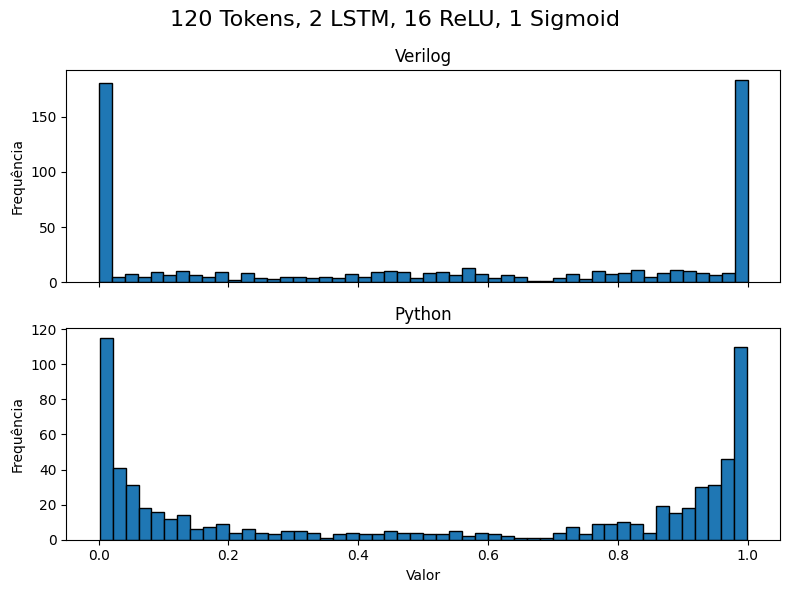

In [8]:

verilog = df['Verilog']
python = df['Python']
fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
fig.suptitle("120 Tokens, 2 LSTM, 16 ReLU, 1 Sigmoid", fontsize=16)

ax[0].hist(verilog, bins=50, edgecolor='black')
ax[0].set_title("Verilog")
ax[0].set_ylabel("Frequência")

ax[1].hist(python, bins=50, edgecolor='black')
ax[1].set_title("Python")
ax[1].set_ylabel("Frequência")
ax[1].set_xlabel("Valor")

plt.tight_layout()
plt.show()

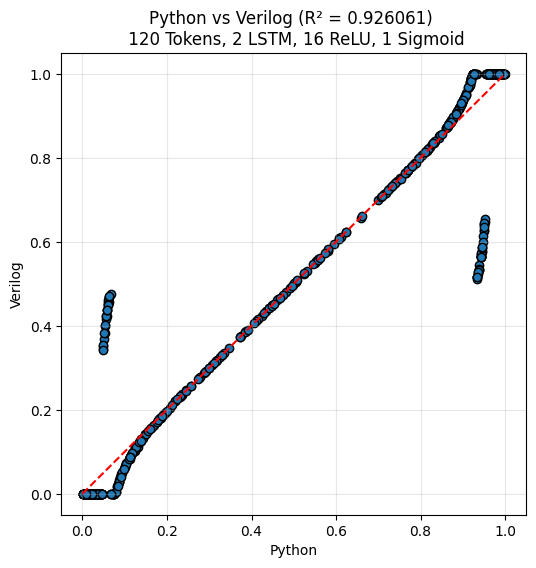

R² = 0.926061


In [9]:
r2 = r2_score(python, verilog)

plt.figure(figsize=(6,6))

plt.scatter(python, verilog,edgecolor='k')

# linha ideal y=x
xmin = min(min(python), min(verilog))
xmax = max(max(python), max(verilog))

plt.plot(
    [xmin, xmax],
    [xmin, xmax],
    'r--',
)

plt.xlabel('Python')
plt.ylabel('Verilog')
plt.title(f'Python vs Verilog (R² = {r2:.6f}) \n 120 Tokens, 2 LSTM, 16 ReLU, 1 Sigmoid')
plt.grid(True, alpha=0.3)

plt.show()


print(f"R² = {r2:.6f}")

Acurácia Verilog: 0.8817
Acurácia Python : 0.8817


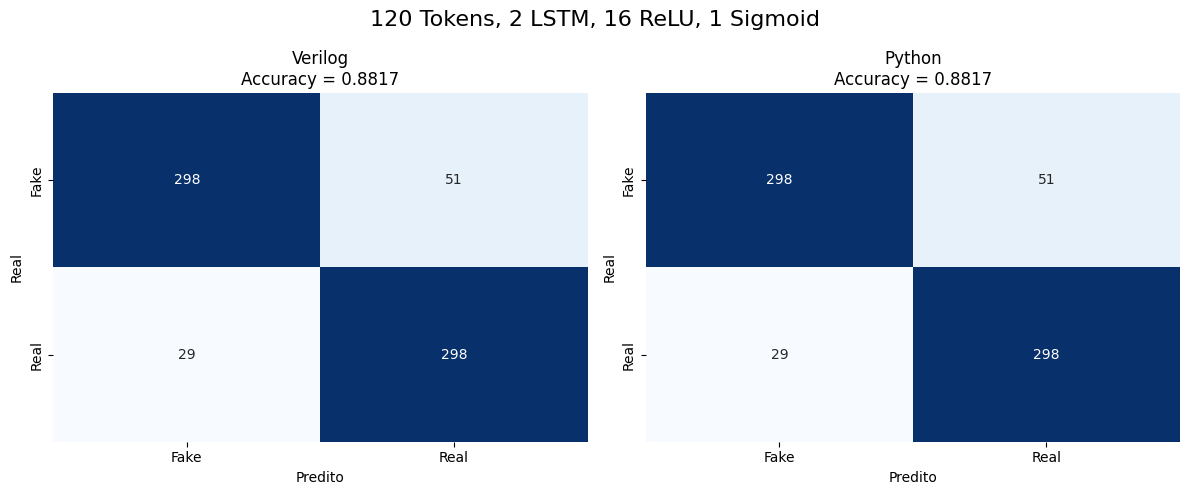

In [10]:
# Converte probabilidades em classes
df["Verilog_pred"] = (df["Verilog"] >= 0.5).astype(int)
df["Python_pred"] = (df["Python"] >= 0.5).astype(int)

# Ground truth
y_true = df["GroundTruth"]

# Predições
y_verilog = df["Verilog_pred"]
y_python = df["Python_pred"]

# Matrizes de confusão
cm_verilog = confusion_matrix(y_true, y_verilog)
cm_python = confusion_matrix(y_true, y_python)

# Acurácia
acc_verilog = accuracy_score(y_true, y_verilog)
acc_python = accuracy_score(y_true, y_python)

print(f"Acurácia Verilog: {acc_verilog:.4f}")
print(f"Acurácia Python : {acc_python:.4f}")

# Plot
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("120 Tokens, 2 LSTM, 16 ReLU, 1 Sigmoid", fontsize=16)

sns.heatmap(
    cm_verilog,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"],
    ax=ax[0]
)
ax[0].set_title(f"Verilog\nAccuracy = {acc_verilog:.4f}")
ax[0].set_xlabel("Predito")
ax[0].set_ylabel("Real")

sns.heatmap(
    cm_python,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"],
    ax=ax[1]
)
ax[1].set_title(f"Python\nAccuracy = {acc_python:.4f}")
ax[1].set_xlabel("Predito")
ax[1].set_ylabel("Real")

plt.tight_layout()
plt.show()